##### Turki Alqahtani 2236938
##### Turki Alghamdi 2235733
##### Mohammed Abu-Talib 2237234
##### Alaa Labban 2235858
##### Salem Eshaaq 2237189

## Importing 

In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import datasets, transforms, models
from sklearn.model_selection import KFold
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Set Random Seed

In [2]:
# Set seed for reproducibility
seed = 65
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

## Setup Device

In [3]:
# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## Dataset & DataLoader (Food-101 from torchvision)

In [4]:
# Enhanced data augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    #it has 50% chance to be flipped right or left to not memorize.
    transforms.RandomHorizontalFlip(p=0.5),
    #rotate images by ±10 degrees randomly
    transforms.RandomRotation(10),
    #changes the brightness and contrast of the image by up to ±25% Randomly.
    transforms.ColorJitter(brightness=0.25, contrast=0.25),
    transforms.ToTensor(),
    #Normalize so the mean of RGB will be roughly 0.
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset (we'll split train dataset for K-Fold later)
full_dataset = datasets.Food101(root="./data", split="train", download=True, transform=train_transform)
test_dataset = datasets.Food101(root="./data", split="test", download=True, transform=test_transform)

## Data Viewing

In [5]:
# Calculate input features
sample_x, _ = full_dataset[0]
in_features = sample_x.numel()  # 224*224*3
num_classes = len(full_dataset.classes)

print(f"Input features: {in_features}")
print(f"Number of classes: {num_classes}")

print(f"Total number of images: {len(full_dataset)}")


from collections import Counter

# Train per-class counts
train_counts = Counter(full_dataset._labels)  # Food101 stores labels in _labels
print("\n"+("-" * 60))
print("\nTrain set per-class counts:")
for idx, count in train_counts.items():
    print(f"{full_dataset.classes[idx]}: {count}")

# Test per-class counts
test_counts = Counter(test_dataset._labels)
print("\n"+("-" * 60))
print("\nTest set per-class counts:")
for idx, count in test_counts.items():
    print(f"{test_dataset.classes[idx]}: {count}")

Input features: 150528
Number of classes: 101
Total number of images: 75750

------------------------------------------------------------

Train set per-class counts:
churros: 750
hot_and_sour_soup: 750
samosa: 750
sashimi: 750
pork_chop: 750
spring_rolls: 750
panna_cotta: 750
beef_tartare: 750
greek_salad: 750
foie_gras: 750
tacos: 750
pad_thai: 750
poutine: 750
ramen: 750
pulled_pork_sandwich: 750
bibimbap: 750
beignets: 750
apple_pie: 750
crab_cakes: 750
risotto: 750
paella: 750
steak: 750
baby_back_ribs: 750
miso_soup: 750
frozen_yogurt: 750
club_sandwich: 750
carrot_cake: 750
falafel: 750
bread_pudding: 750
chicken_wings: 750
gnocchi: 750
caprese_salad: 750
creme_brulee: 750
escargots: 750
chocolate_cake: 750
tiramisu: 750
spaghetti_bolognese: 750
mussels: 750
scallops: 750
baklava: 750
edamame: 750
macaroni_and_cheese: 750
pancakes: 750
garlic_bread: 750
beet_salad: 750
onion_rings: 750
red_velvet_cake: 750
grilled_salmon: 750
chicken_curry: 750
deviled_eggs: 750
caesar_salad: 75

## MODEL: ResNet18 FT

### Why ResNet18 Instead of ANN?

This project uses **ResNet18** as the core model instead of a simple Artificial Neural Network (ANN). The main reason is:

####  Handling Image Data
- ANN requires flattening images into a single vector, which **destroys the spatial relationships** between pixels.
- ResNet18 (a Convolutional Neural Network) **preserves spatial structure**, allowing the model to detect edges, textures, and shapes.

For example: check these 2 images

![Food101 Sample](64846.jpg)                 ![Food101 Sample](90831.jpg)

Both images belong to different classes, but they share similar elements such as the plate and possibly the table.



- An **ANN** would treat each image independently and might memorize irrelevant features like plates or tables, which reduces generalization.

- **ResNet18**, on the other hand, learns **feature relationships**, focusing on the important parts (e.g., the food inside the plate) while ignoring background elements.



**In short**: ResNet18 is designed for image recognition, while ANN is not suitable for high-dimensional raw image data.

In [6]:
def make_model(num_classes):
    # Load ResNet18 pretrained on ImageNet, uses learned features from millions of images.
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    # Replace the last layer
    model.fc = nn.Sequential(
        # prevent overfitting
        nn.Dropout(0.2),
        nn.Linear(512, num_classes)
    )
    return model.to(device)

## HyperParameter

In [ ]:
k_folds = 3 # Number of Folds
num_epochs = 30  # iteration in each fold             
batch_size = 125 # batch size, 125 images per training step         
lr = 0.0003 # learning rate
weight_decay = 0.0001 # L2 regularization, slightly shrinking model weights each step to reduce overfitting.
label_smoothing = 0.1 #the target labels are slightly softened. for generalization                
num_workers = 2 #this for pararell to speedup the computation
pin_memory = True #this to speed up moving cpu to gpu, like reserve your place in memoray.

## K-Fold Cross Validation

In [ ]:
kfold = KFold(n_splits=k_folds, shuffle=True, random_state=seed)

fold_accuracies = [] #saves our 3 fold final accuracy
all_y_true, all_y_scores = [], [] #saves all y output model after train and all y real output

print("\n" + "="*60)
print(f"Starting {k_folds}-Fold Cross Validation")
print("="*60)
#indices for train and validate in each fold in train_ids, val_ids.
for fold, (train_ids, val_ids) in enumerate(kfold.split(full_dataset)):
    print(f"\nFOLD {fold+1}/{k_folds}")
    print("-"*60)
    # Load train (2 Folds)
    train_loader = DataLoader(
        full_dataset, batch_size=batch_size,
        sampler=SubsetRandomSampler(train_ids),
        num_workers=num_workers, pin_memory=pin_memory
    )
    # Load Validate (1 Fold)
    val_loader = DataLoader(
        full_dataset, batch_size=batch_size,
        sampler=SubsetRandomSampler(val_ids),
        num_workers=num_workers, pin_memory=pin_memory
    )
    #builds and prepares the model for training
    model = make_model(num_classes)

    #LossFuntion with Label Smoothing slightly softens the target labels to reduce overconfidence and improve generalization.
    #For Example Output = (0, 1, 0) with 0.1 label smoothing it will be Output (0.05, 0.9, 0.05).
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    #OptimizerFuntion that updates model weights using gradients
    #Weight decay discourages large weights to reduce overfitting, helping the model generalize better.
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Cosine schedule with warmup
    #Calculates the total number of training steps (batches) across all epochs.
    total_steps = num_epochs * len(train_loader)
    #Sets warmup period to 10% of total steps. During this, the LR gradually increases from 0.
    warmup_steps = int(0.1 * total_steps)

    #Defines a function that calculates a scaling factor for the learning rate depending on the current step.
    def lr_lambda(step):
        #Warmup phase: scales LR linearly from 0 → 1 over warmup_steps.
        if step < warmup_steps:
            #max(1, warmup_steps) prevents division by zero.
            return float(step) / max(1, warmup_steps)
        # cosine decay after warmup
        #After warmup, compute progress through the remaining training steps (0 → 1).
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        #Applies cosine decay: LR starts at base, gradually decreases to near 0 following a cosine curve.
        return 0.5 * (1.0 + np.cos(np.pi * progress))
    
    #Sometimes if you start training with a high LR immediately, the model can diverge or overshoot because the weights are random at first.
    #that the difference between warmup and cosine decay

    #Creates a PyTorch scheduler that updates the optimizer’s LR according to lr_lambda at each step.
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    # ----- Train -----
    for epoch in range(num_epochs):
        model.train() #Model set to train mode
        running_loss = 0.0

        for X, y in train_loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad() #Delete previous gradients
            logits = model(X) # pass input to model and return predictions
            loss = criterion(logits, y) #calculate the loss
            loss.backward() #give me the gradient of which weights might change to decrease the loss
            optimizer.step() #updates the parameter of the model (AdamW)
            scheduler.step() #updates the Learning Rate accouding to our schedular
            
            
            running_loss += loss.item()

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss/len(train_loader):.4f}")

    # ----- Validate -----
    #model to evaluate mode (so the dropout won't happen)
    model.eval()
    correct = total = 0
    fold_y_true, fold_y_scores = [], []

    #no gradient since it's validates
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(X) # gives preds
            probs = torch.softmax(logits, dim=1) #preds to perecent

            preds = logits.argmax(1) #gives us indicies of highest output (which means the class)
            total += y.size(0)
            correct += (preds == y).sum().item()

            fold_y_true.extend(y.cpu().numpy()) #save 
            fold_y_scores.extend(probs.cpu().numpy()) #save

    fold_acc = 100 * correct / total #accuracy
    fold_accuracies.append(fold_acc) #save
    all_y_true.extend(fold_y_true) #save
    all_y_scores.extend(fold_y_scores) #save
    fold_y_pred = np.argmax(fold_y_scores, axis=1) # takes pred classes

    precision = precision_score(fold_y_true, fold_y_pred, average="macro") #precesion
    recall = recall_score(fold_y_true, fold_y_pred, average="macro") #recall
    f1 = f1_score(fold_y_true, fold_y_pred, average="macro") #f1

    print(f"  Fold {fold+1} Validation Accuracy: {fold_acc:.2f}%")
    print(f"  Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

# ----- CV summary -----
avg_accuracy = np.mean(fold_accuracies) #avg
std_accuracy = np.std(fold_accuracies) #standard devation

print("\n" + "="*60)
print("K-FOLD CROSS VALIDATION RESULTS")
print("="*60)
for i, acc in enumerate(fold_accuracies):
    print(f"Fold {i+1} Accuracy: {acc:.2f}%")
print(f"\nAverage Accuracy: {avg_accuracy:.2f}% (+/- {std_accuracy:.2f}%)")



Starting 3-Fold Cross Validation

FOLD 1/3
------------------------------------------------------------
  Epoch [5/30] Loss: 1.6904
  Epoch [10/30] Loss: 1.1948
  Epoch [15/30] Loss: 0.9839
  Epoch [20/30] Loss: 0.8901
  Epoch [25/30] Loss: 0.8473
  Epoch [30/30] Loss: 0.8381
  Fold 1 Validation Accuracy: 72.30%
  Precision: 0.7212, Recall: 0.7228, F1: 0.7209

FOLD 2/3
------------------------------------------------------------
  Epoch [5/30] Loss: 1.6892
  Epoch [10/30] Loss: 1.1928
  Epoch [15/30] Loss: 0.9815
  Epoch [20/30] Loss: 0.8896
  Epoch [25/30] Loss: 0.8472
  Epoch [30/30] Loss: 0.8368
  Fold 2 Validation Accuracy: 72.00%
  Precision: 0.7187, Recall: 0.7214, F1: 0.7191

FOLD 3/3
------------------------------------------------------------
  Epoch [5/30] Loss: 1.6898
  Epoch [10/30] Loss: 1.1912
  Epoch [15/30] Loss: 0.9820
  Epoch [20/30] Loss: 0.8890
  Epoch [25/30] Loss: 0.8476
  Epoch [30/30] Loss: 0.8376
  Fold 3 Validation Accuracy: 72.14%
  Precision: 0.7202, Recall

## ROC Curve

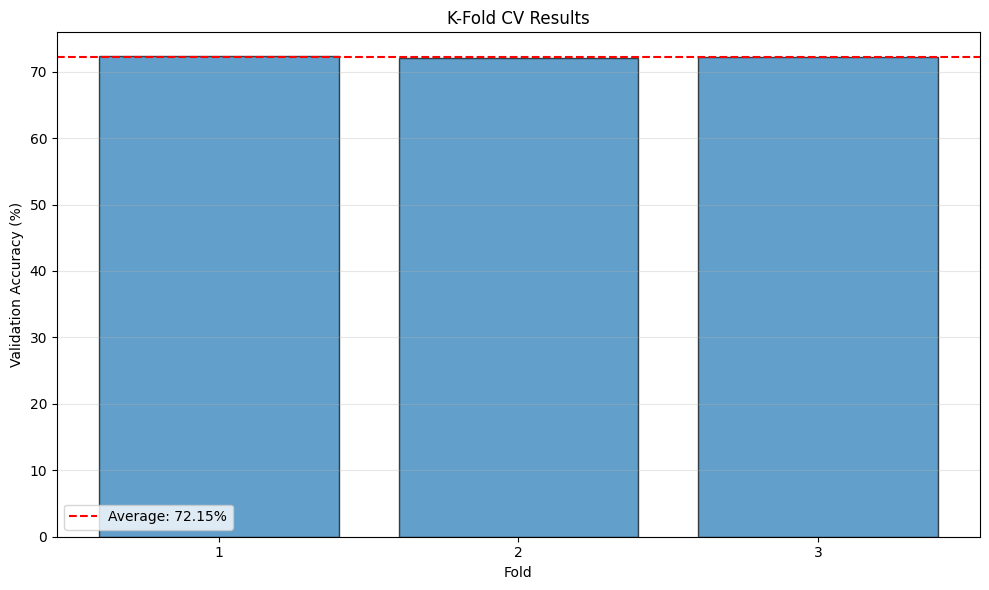


Generating ROC Curve (first 5 classes)...


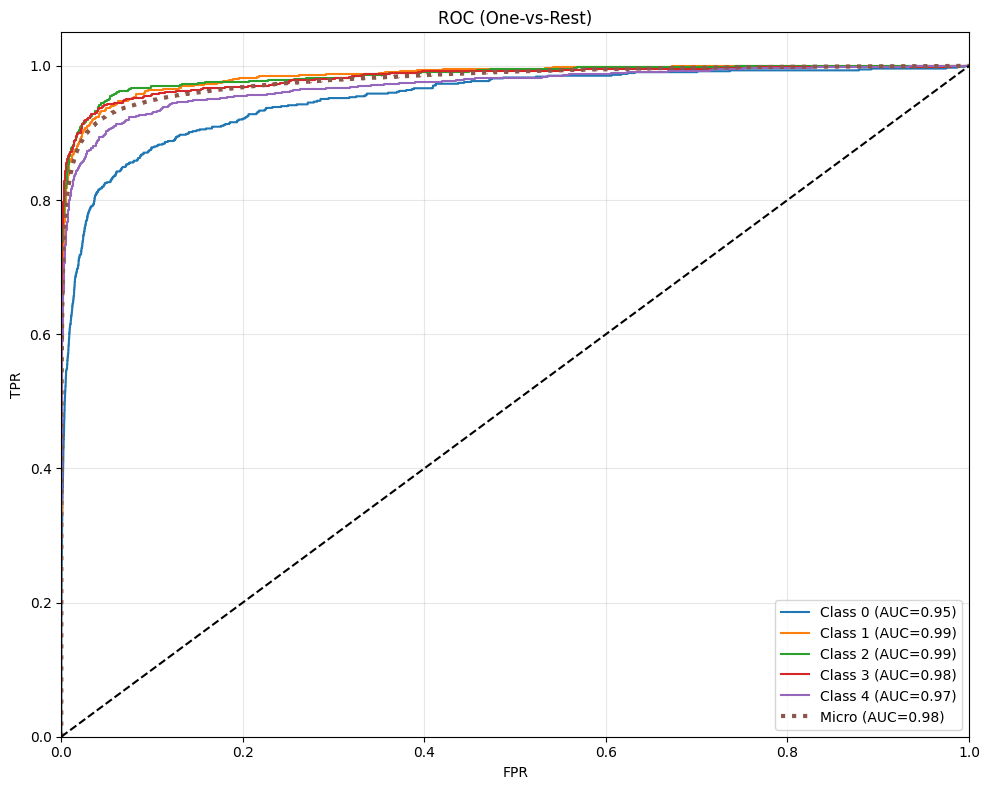

In [ ]:
# ----- Plot Fold acc -----
plt.figure(figsize=(10, 6))
plt.bar(range(1, k_folds + 1), fold_accuracies, alpha=0.7, edgecolor='black')
plt.axhline(y=avg_accuracy, color='r', linestyle='--', label=f'Average: {avg_accuracy:.2f}%')
plt.xlabel('Fold'); plt.ylabel('Validation Accuracy (%)')
plt.title('K-Fold CV Results'); plt.xticks(range(1, k_folds + 1))
plt.legend(); plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()
# ----- ROC for a subset of classes -----
print("\n" + "="*60)
print("Generating ROC Curve (first 5 classes)...")
print("="*60)
all_y_true = np.array(all_y_true); all_y_scores = np.array(all_y_scores)
y_true_bin = label_binarize(all_y_true, classes=range(num_classes))

fpr, tpr, roc_auc = {}, {}, {}
plt.figure(figsize=(10, 8))
for i in range(min(5, num_classes)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC={roc_auc[i]:.2f})')

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), all_y_scores.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
plt.plot(fpr["micro"], tpr["micro"], label=f'Micro (AUC={roc_auc["micro"]:.2f})',
         linestyle=':', linewidth=3)
plt.plot([0,1],[0,1],'k--'); plt.xlim([0,1]); plt.ylim([0,1.05])
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC (One-vs-Rest)')
plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 6) Evaluate on test set


In [10]:
# Final test on held-out test set
print("\n" + "=" * 60)
print("Final Test on Test Set (using last fold's model)")
print("=" * 60)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                         num_workers=num_workers, pin_memory=pin_memory)

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        preds = model(X).argmax(1)
        total += y.size(0)
        correct += (preds == y).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")


Final Test on Test Set (using last fold's model)
Test Accuracy: 78.42%
